In [1]:
from pctk import multicellds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import os
from scipy.interpolate import griddata
import matplotlib as mpl

In [2]:
output_folder = "../../../../output/" 

In [3]:
runs = []
for root, dirs, files in os.walk(output_folder):
    runs = files
    break

runs

['output00000117_cells.mat',
 'output00000073_microenvironment0.mat',
 'output00000079_cell_neighbor_graph.txt',
 'output00000037.xml',
 'final_spring_attached_cells_graph.txt',
 'output00000102_attached_cells_graph.txt',
 'snapshot00000081.svg',
 'output00000052_microenvironment0.mat',
 'output00000047_cell_neighbor_graph.txt',
 'output00000029_cells.mat',
 'output00000070_cells.mat',
 'output00000096.xml',
 'output00000059_cell_neighbor_graph.txt',
 'snapshot00000031.svg',
 'output00000036_cell_neighbor_graph.txt',
 'output00000033_spring_attached_cells_graph.txt',
 'snapshot00000037.svg',
 'snapshot00000010.svg',
 'output00000018_spring_attached_cells_graph.txt',
 'output00000108_cells.mat',
 'output00000014_attached_cells_graph.txt',
 'output00000030_spring_attached_cells_graph.txt',
 'output00000026_spring_attached_cells_graph.txt',
 'snapshot00000113.svg',
 'output00000043_microenvironment0.mat',
 'snapshot00000068.svg',
 'output00000060_cells.mat',
 'output00000037_attached_cell

In [4]:
mcds_reader = multicellds.MultiCellDS(output_folder)

In [5]:
mcds_reader.cell_columns

['ID',
 'x_position',
 'y_position',
 'z_position',
 'total_volume',
 'cell_type',
 'cycle_model',
 'current_phase',
 'elapsed_time_in_phase',
 'nuclear_volume',
 'cytoplasmic_volume',
 'fluid_fraction',
 'calcified_fraction',
 'x_orientation',
 'y_orientation',
 'z_orientation',
 'polarity',
 'x_velocity',
 'y_velocity',
 'z_velocity',
 'pressure',
 'number_of_nuclei',
 'total_attack_time',
 'contact_with_basement_membrane',
 'current_cycle_phase_exit_rate',
 'elapsed_time_in_phase',
 'dead',
 'current_death_model',
 'x_death_rates',
 'y_death_rates',
 'cytoplasmic_biomass_change_rate',
 'nuclear_biomass_change_rate',
 'fluid_change_rate',
 'calcification_rate',
 'target_solid_cytoplasmic',
 'target_solid_nuclear',
 'target_fluid_fraction',
 'radius',
 'nuclear_radius',
 'surface_area',
 'cell_cell_adhesion_strength',
 'cell_BM_adhesion_strength',
 'cell_cell_repulsion_strength',
 'cell_BM_repulsion_strength',
 'cell_adhesion_affinities',
 'relative_maximum_adhesion_distance',
 'maxim

In [6]:
mcds_reader = multicellds.MultiCellDS(output_folder)
vol_idx = 4
name2idx = {n:i for i,n in enumerate(mcds_reader.cell_columns)}

data = []
for t, a in mcds_reader.microenvironment_as_matrix_iterator():
    data.append((t/60., (a[5].sum() / len(a[5])), (a[6].sum() / len(a[6])), (a[4].sum() / len(a[4])) ))

df_substrates = pd.DataFrame(data=data, columns=["time", "glucose", "acetate", "oxygen"]).set_index("time")

data = []
for t, a in mcds_reader.cells_as_matrix_iterator():
    total_volume = a[:,4].sum() # um3
    scaled_volume = total_volume / 10**12 # mL
    density = 1.04 # g/ml
    solid_fraction = 0.25
    biomass = scaled_volume * density * solid_fraction / 2e-8 
    #print("total volume is ", total_volume)
    
    data.append((t/60., a.shape[0], a[:,-8].mean(), biomass, a[:,-1].mean(), a[:,-2].mean(),
     a[:,-3].mean(), a[:,-4].mean(), a[:,-5].mean()))

df_cells = pd.DataFrame(data=data, columns=["time", "n_cells", "growth_rate", "total_biomass", "motility_speed_fraction",
 "motility_atp_used_this_step", "motility_atp_rate_cell", "motility_atp_flux", "atp_flux"]).set_index("time")

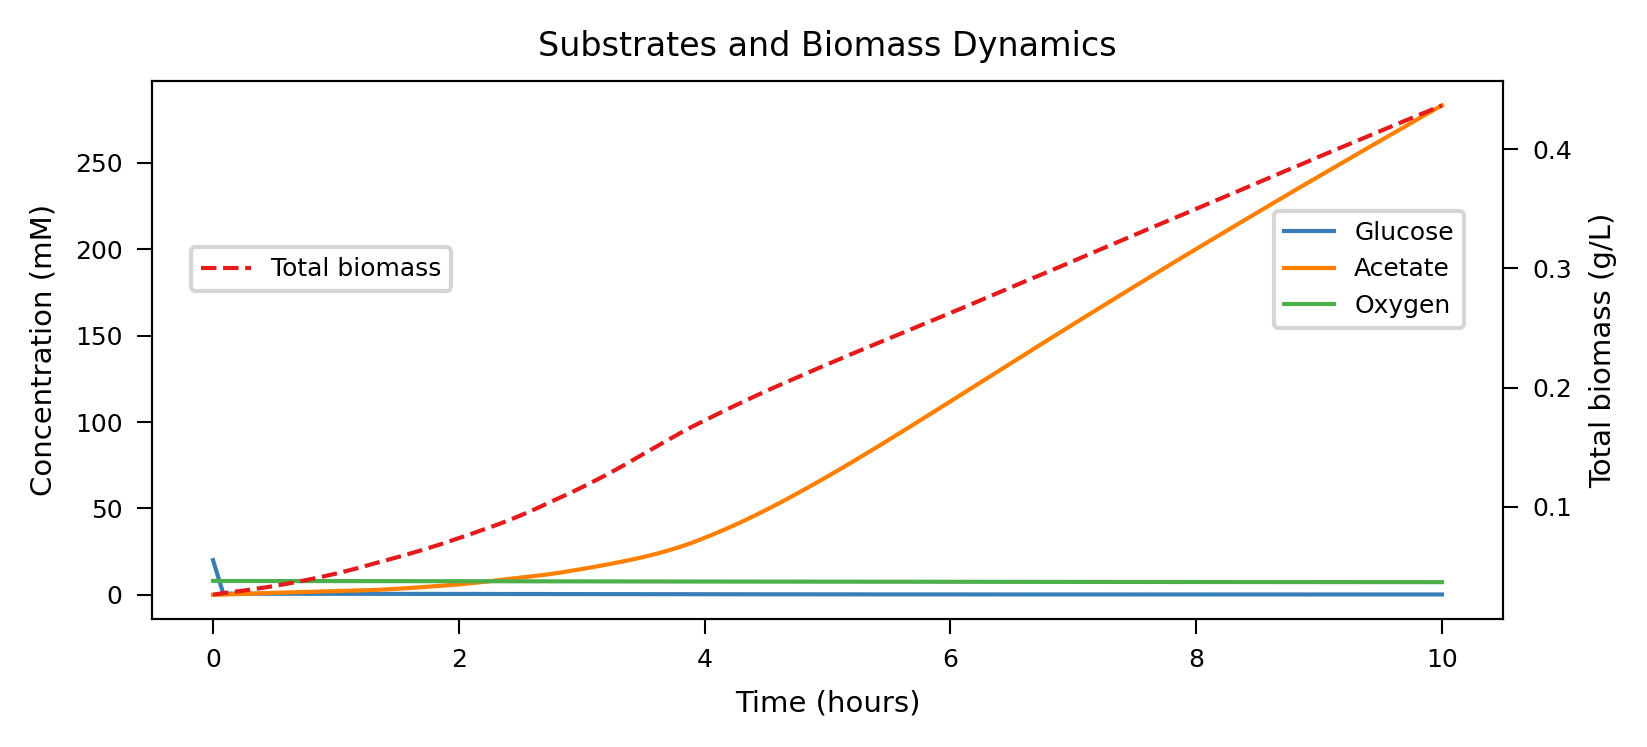

In [7]:

# Nature style settings
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 6
mpl.rcParams['ytick.labelsize'] = 6
mpl.rcParams['legend.fontsize'] = 6
mpl.rcParams['figure.titlesize'] = 8
mpl.rcParams['lines.linewidth'] = 1.0
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5

# Figure size for single column (approx 89mm / 3.5 inches)
fig_width = 5.5  # inches
fig_height = 2.5 # inches

# Create the figure and the first axis (left)
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height), dpi=300)

# Colors
colors = {'glucose': '#377eb8', 'acetate': '#ff7f00', 'oxygen': '#4daf4a', 'biomass': '#e41a1c'}

# --- LEFT AXIS (Substrates) ---
l1, = ax1.plot(df_substrates.index, df_substrates["glucose"], label="Glucose", color=colors['glucose'])
l2, = ax1.plot(df_substrates.index, df_substrates["acetate"], label="Acetate", color=colors['acetate'])
l3, = ax1.plot(df_substrates.index, df_substrates["oxygen"], label="Oxygen", color=colors['oxygen'])

ax1.set_xlabel("Time (hours)")
ax1.set_ylabel("Concentration (mM)")

# --- RIGHT AXIS (Biomass) ---
ax2 = ax1.twinx()
l4, = ax2.plot(df_cells.index, df_cells["total_biomass"], label="Total biomass", color=colors['biomass'], linestyle="--")
ax2.set_ylabel("Total biomass (g/L)")

# --- 4-AXIS "BOX" STYLE ---
# To have a full box (4 spines), we ensure visibility is True on both axes
# We generally keep the ticks only on the relevant sides, but show the spine lines.
ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True) # Overlays ax1, ensures top line is drawn

# --- DUAL LEGENDS ---

# Legend 1: Substrates (Left side)
lines_1 = [l1, l2, l3]
labels_1 = [l.get_label() for l in lines_1]
# 'loc' controls position. 'center left' places it inside the plot on the left.
# bbox_to_anchor can be used to move it outside if preferred.
leg1 = ax1.legend(lines_1, labels_1, loc="center right", bbox_to_anchor=(0.98, 0.65), frameon=True, fancybox=True)

# Legend 2: Biomass (Right side)
lines_2 = [l4]
labels_2 = [l.get_label() for l in lines_2]
leg2 = ax2.legend(lines_2, labels_2, loc="center left", bbox_to_anchor=(0.02, 0.65), frameon=True, fancybox=True)

# Important: When using dual legends on the same axis object (or shared axes), 
# sometimes the second legend overwrites the first. 
# However, since we attached leg1 to ax1 and leg2 to ax2, they naturally coexist.
# If you ever need two legends on ONE axis, you must use ax.add_artist(first_legend).

plt.title("Substrates and Biomass Dynamics")
plt.tight_layout()
plt.show()

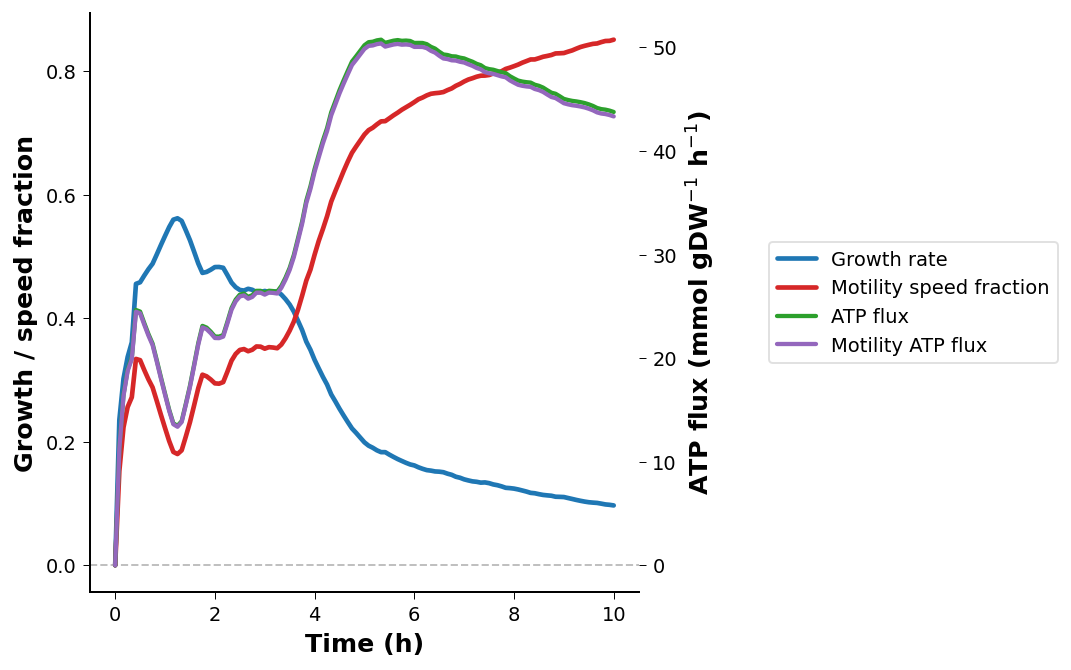

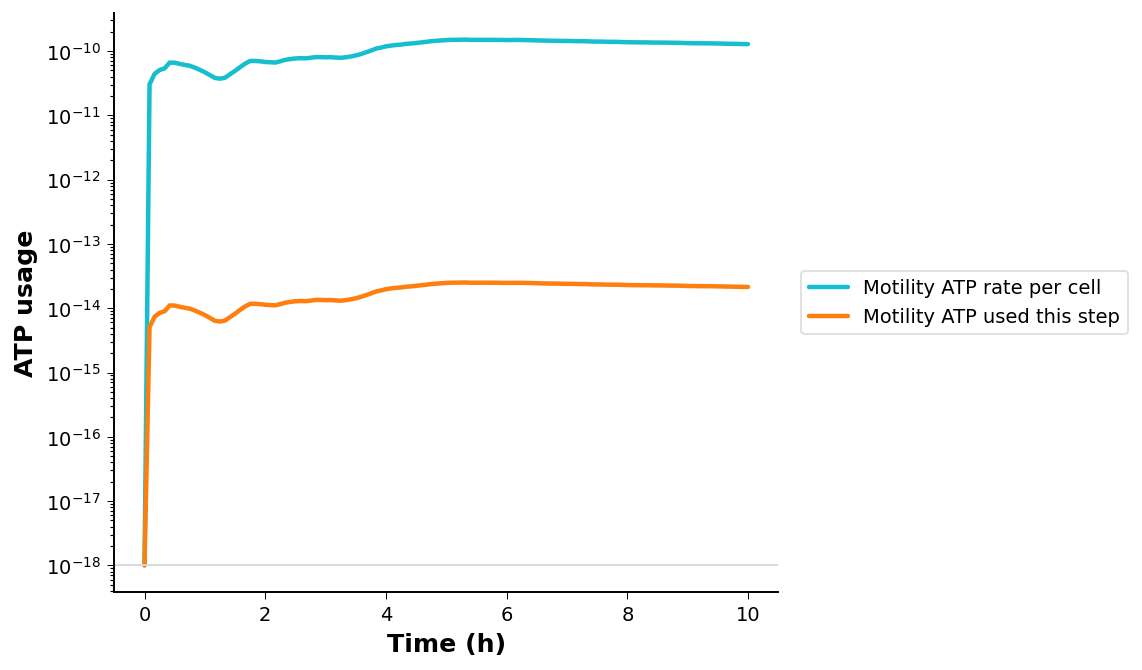

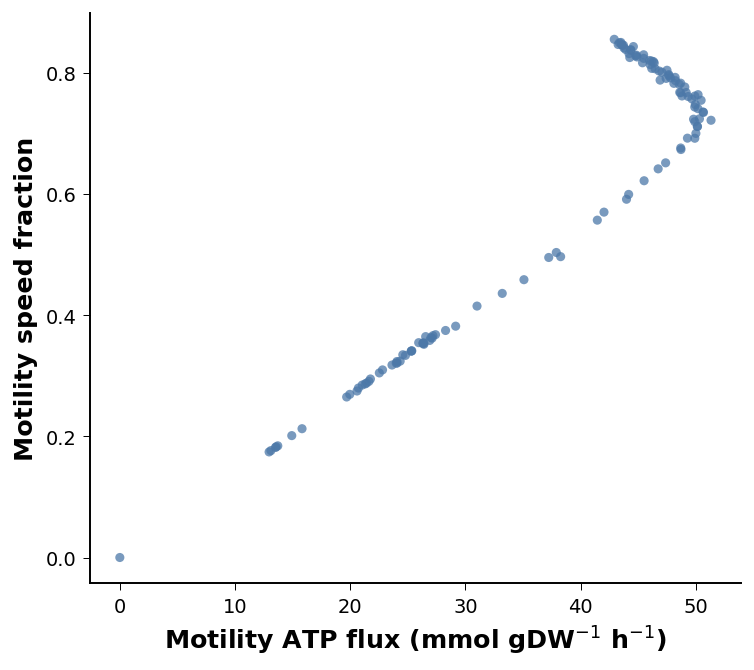

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- global style ----------
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 2.2,
    "lines.solid_capstyle": "round",
    "lines.solid_joinstyle": "round",
})

# optional smoothing
smooth = df_cells.rolling(window=5, min_periods=1).mean()

# nicer colors
colors = {
    "growth_rate": "#1f77b4",             # blue
    "motility_speed_fraction": "#d62728", # red
    "atp_flux": "#2ca02c",                # green
    "motility_atp_flux": "#9467bd",       # purple
    "motility_atp_rate_cell": "#17becf",  # teal
    "motility_atp_used_this_step": "#ff7f0e", # orange
}

# ---------- plot 1: overview ----------
fig, ax1 = plt.subplots(figsize=(8.2, 4.8))

l1, = ax1.plot(
    smooth.index, smooth["growth_rate"],
    color=colors["growth_rate"], lw=2.4, label="Growth rate"
)
l2, = ax1.plot(
    smooth.index, smooth["motility_speed_fraction"],
    color=colors["motility_speed_fraction"], lw=2.4, label="Motility speed fraction"
)

ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Growth / speed fraction")
ax1.axhline(0, color="0.75", lw=1.0, ls="--", zorder=0)

ax2 = ax1.twinx()
l3, = ax2.plot(
    smooth.index, smooth["atp_flux"],
    color=colors["atp_flux"], lw=2.2, label="ATP flux"
)
l4, = ax2.plot(
    smooth.index, smooth["motility_atp_flux"],
    color=colors["motility_atp_flux"], lw=2.2, label="Motility ATP flux"
)
ax2.set_ylabel(r"ATP flux (mmol gDW$^{-1}$ h$^{-1}$)")

# subtle spines
ax1.spines["left"].set_color("0.2")
ax1.spines["bottom"].set_color("0.2")
ax2.spines["right"].set_color("0.2")

# combined legend outside
lines = [l1, l2, l3, l4]
labels = [l.get_label() for l in lines]
ax1.legend(
    lines, labels,
    frameon=True, facecolor="white", edgecolor="0.85",
    loc="center left", bbox_to_anchor=(1.22, 0.5)
)

fig.tight_layout()
plt.show()

# ---------- plot 2: motility energetics ----------
fig, ax = plt.subplots(figsize=(8.2, 4.8))

eps = 1e-18
ax.plot(
    smooth.index, np.maximum(smooth["motility_atp_rate_cell"], eps),
    color=colors["motility_atp_rate_cell"], lw=2.3, label="Motility ATP rate per cell"
)
ax.plot(
    smooth.index, np.maximum(smooth["motility_atp_used_this_step"], eps),
    color=colors["motility_atp_used_this_step"], lw=2.3, label="Motility ATP used this step"
)

ax.set_yscale("log")
ax.set_xlabel("Time (h)")
ax.set_ylabel("ATP usage")
ax.axhline(eps, color="0.85", lw=1.0)

ax.legend(
    frameon=True, facecolor="white", edgecolor="0.85",
    loc="center left", bbox_to_anchor=(1.02, 0.5)
)

fig.tight_layout()
plt.show()

# ---------- plot 3: phase plot ----------
fig, ax = plt.subplots(figsize=(5.4, 4.8))

ax.scatter(
    df_cells["motility_atp_flux"],
    df_cells["motility_speed_fraction"],
    s=22, alpha=0.75,
    color="#4c78a8", edgecolors="none"
)

ax.set_xlabel(r"Motility ATP flux (mmol gDW$^{-1}$ h$^{-1}$)")
ax.set_ylabel("Motility speed fraction")

fig.tight_layout()
plt.show()

In [9]:
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import glob
import os

# ---- simulation domain ----
DOMAIN_X = (-150.0, 150.0)
DOMAIN_Y = (-150.0, 150.0)

SOURCES = np.array([
    [-95.0, 105.0],
    [-95.0, -95.0],
    [105.0,   5.0],
])

SOURCE_NAMES = ["source_0", "source_1", "source_2"]

# ---- shared plot style (matches overview cell) ----
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 2.2,
    "lines.solid_capstyle": "round",
    "lines.solid_joinstyle": "round",
})


def get_cell_columns_fixed(output_folder, sep="_"):
    """
    Parse cell column labels from initial.xml handling ALL label sizes.

    pctk's built-in _get_cell_columns() silently skips labels with size > 3,
    causing wrong column indices for any variable that follows them. This
    function correctly expands every label so the returned list length equals
    the number of columns in the .mat cell matrix.
    """
    xml_fname = os.path.join(output_folder, "initial.xml")
    tree = ET.parse(xml_fname)
    root = tree.getroot()

    def find_simplified(node):
        for child in node:
            if child.tag == "simplified_data" and child.attrib.get("source") == "PhysiCell":
                return child
        for child in node:
            result = find_simplified(child)
            if result is not None:
                return result

    node = find_simplified(root.find("cellular_information"))
    labels = node.find("labels")

    cell_columns = []
    for child in labels:
        name = child.text.strip()
        size = int(child.attrib["size"])
        if size == 1:
            cell_columns.append(name)
        elif size == 2:
            cell_columns.extend([f"x{sep}{name}", f"y{sep}{name}"])
        elif size == 3:
            cell_columns.extend([f"x{sep}{name}", f"y{sep}{name}", f"z{sep}{name}"])
        else:
            # Arbitrary size: use indexed suffixes, e.g. secretion_rates_0, _1, ...
            cell_columns.extend([f"{name}{sep}{i}" for i in range(size)])

    return cell_columns


def _ensure_cells_rows(a, ncols_expected):
    """Return matrix shaped (n_cells, n_features)."""
    a = np.asarray(a)

    if a.ndim != 2:
        raise ValueError(f"Expected 2D matrix, got shape {a.shape}")

    if a.shape[1] == ncols_expected:
        return a
    if a.shape[0] == ncols_expected:
        return a.T

    raise ValueError(
        f"Cannot infer matrix orientation: matrix shape={a.shape}, "
        f"expected one axis to equal number of columns={ncols_expected}"
    )


def build_per_cell_dataframe_safe(mcds_reader, sample_every=1, verbose=True):
    # Use the fixed column reader instead of mcds_reader.cell_columns
    cols = get_cell_columns_fixed(mcds_reader._output_folder)
    name2idx = {n: i for i, n in enumerate(cols)}

    needed = [
        "ID",
        "x_position",
        "y_position",
        "z_position",
        "total_volume",
        "fluid_fraction",
        "growth_rate",
        "atp_flux",
        "motility_atp_flux",
        "motility_atp_rate_cell",
        "motility_atp_used_this_step",
        "motility_speed_fraction",
    ]

    missing = [c for c in needed if c not in name2idx]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    dfs = []

    for k, (t, a) in enumerate(mcds_reader.cells_as_matrix_iterator()):
        if k % sample_every != 0:
            continue

        a = _ensure_cells_rows(a, len(cols))
        time_h = t / 60.0

        df_t = pd.DataFrame({
            "time": np.full(a.shape[0], time_h),
            "ID": a[:, name2idx["ID"]].astype(int),
            "x": a[:, name2idx["x_position"]],
            "y": a[:, name2idx["y_position"]],
            "z": a[:, name2idx["z_position"]],
            "total_volume": a[:, name2idx["total_volume"]],
            "fluid_fraction": a[:, name2idx["fluid_fraction"]],
            "growth_rate": a[:, name2idx["growth_rate"]],
            "atp_flux": a[:, name2idx["atp_flux"]],
            "motility_atp_flux": a[:, name2idx["motility_atp_flux"]],
            "motility_atp_rate_cell": a[:, name2idx["motility_atp_rate_cell"]],
            "motility_atp_used_this_step": a[:, name2idx["motility_atp_used_this_step"]],
            "motility_speed_fraction": a[:, name2idx["motility_speed_fraction"]],
        })

        dfs.append(df_t)

        if verbose and len(dfs) == 1:
            print("First sampled snapshot")
            print("matrix shape after orientation fix:", a.shape)
            print("x range:", df_t["x"].min(), df_t["x"].max())
            print("y range:", df_t["y"].min(), df_t["y"].max())
            print("atp_flux range:", df_t["atp_flux"].min(), df_t["atp_flux"].max())
            print("motility_atp_flux range:", df_t["motility_atp_flux"].min(), df_t["motility_atp_flux"].max())
            print("growth_rate range:", df_t["growth_rate"].min(), df_t["growth_rate"].max())
            print("speed_fraction range:", df_t["motility_speed_fraction"].min(), df_t["motility_speed_fraction"].max())

    return pd.concat(dfs, ignore_index=True)


In [10]:
df_cells_long = build_per_cell_dataframe_safe(mcds_reader, sample_every=1, verbose=True)

First sampled snapshot
matrix shape after orientation fix: (200, 122)
x range: -139.61330598650437 136.23075170772177
y range: -138.78590621899087 139.84496568466068
atp_flux range: 0.0 0.0
motility_atp_flux range: 0.0 0.0
growth_rate range: 0.0 0.0
speed_fraction range: 0.0 0.0


In [11]:
df_cells_long

,time,ID,x,y,z,total_volume,fluid_fraction,growth_rate,atp_flux,motility_atp_flux,motility_atp_rate_cell,motility_atp_used_this_step,motility_speed_fraction
0,0.0,0,-62.764668,-87.722952,0.0,10.000000,0.75,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0
1,0.0,1,96.281086,-96.954540,0.0,10.000000,0.75,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0
2,0.0,2,112.621209,29.498695,0.0,10.000000,0.75,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0
3,0.0,3,-94.754982,-41.246715,0.0,10.000000,0.75,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0
4,0.0,4,-103.666658,105.479909,0.0,10.000000,0.75,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
174173,10.0,2911,110.157905,-6.832865,0.0,9.046961,0.75,0.687739,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0
174174,10.0,2912,130.201701,27.404772,0.0,9.223736,0.75,0.000000,73.015645,72.515645,1.739049e-10,2.898416e-14,1.0
174175,10.0,2913,-68.949627,-82.206267,0.0,8.140344,0.75,0.000000,74.178863,73.678863,1.559405e-10,2.599009e-14,1.0
174176,10.0,2914,-67.274088,-89.315562,0.0,8.647203,0.75,0.000000,74.178863,73.678863,1.656502e-10,2.760836e-14,1.0


In [12]:
def annotate_with_source_info(df, sources=SOURCES, source_names=SOURCE_NAMES):
    out = df.copy()

    xy = out[["x", "y"]].to_numpy(dtype=float)
    dists = np.linalg.norm(xy[:, None, :] - sources[None, :, :], axis=2)

    for i in range(sources.shape[0]):
        out[f"distance_to_source_{i}"] = dists[:, i]

    nearest_idx = np.argmin(dists, axis=1)
    out["nearest_source"] = nearest_idx
    out["nearest_source_name"] = [source_names[i] for i in nearest_idx]
    out["distance_to_nearest_source"] = dists[np.arange(len(out)), nearest_idx]

    return out

In [13]:
df_cells_long = annotate_with_source_info(df_cells_long)

In [14]:
def get_snapshot(df, time_h, tol=1e-9):
    times = np.sort(df["time"].unique())
    nearest_time = times[np.argmin(np.abs(times - time_h))]
    snap = df[np.isclose(df["time"], nearest_time, atol=tol)].copy()
    return nearest_time, snap

In [15]:
t_final, df_final = get_snapshot(df_cells_long, df_cells_long["time"].max())
print("Using snapshot at time =", t_final)

Using snapshot at time = 10.0


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap

def plot_snapshot_as_cells(
    df,
    color_col="atp_flux",
    sources=SOURCES,
    source_names=SOURCE_NAMES,
    figsize=(8, 8),
    cmap="viridis",
    vmin=None,
    vmax=None,
    edgecolor="black",
    linewidth=0.35,
    alpha=0.95,
):
    plot_df = df.copy()

    # robust color limits if not provided
    if vmin is None:
        vmin = np.percentile(plot_df[color_col], 2)
    if vmax is None:
        vmax = np.percentile(plot_df[color_col], 98)
        if vmax <= vmin:
            vmax = plot_df[color_col].max()

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = get_cmap(cmap)

    fig, ax = plt.subplots(figsize=figsize)

    # draw cells as circles in data coordinates
    for _, row in plot_df.iterrows():
        x = row["x"]
        y = row["y"]
        V = row["total_volume"]  # µm^3

        # PhysiCell-like radius from volume
        r = (3.0 * V / (4.0 * np.pi)) ** (1.0 / 3.0)

        color = cmap_obj(norm(row[color_col]))

        circ = Circle(
            (x, y),
            r,
            facecolor=color,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha
        )
        ax.add_patch(circ)

    # draw sources
    for i, (sx, sy) in enumerate(sources):
        ax.scatter(
            sx, sy,
            marker="*",
            s=260,
            color="red",
            edgecolors="black",
            linewidths=0.8,
            zorder=10
        )
        ax.text(
            sx + 5, sy + 5,
            source_names[i],
            color="red",
            fontsize=12,
            weight="bold"
        )

    ax.set_xlabel("x (µm)", weight="bold")
    ax.set_ylabel("y (µm)", weight="bold")
    ax.set_title(f"Cells colored by {color_col}", fontsize=14)
    ax.set_aspect("equal")

    # set limits from data with small padding
    xmin, xmax = plot_df["x"].min(), plot_df["x"].max()
    ymin, ymax = plot_df["y"].min(), plot_df["y"].max()
    pad = 10
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    sm = ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.92)
    cbar.set_label(color_col, weight="bold")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2424835/269260241.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = get_cmap(cmap)


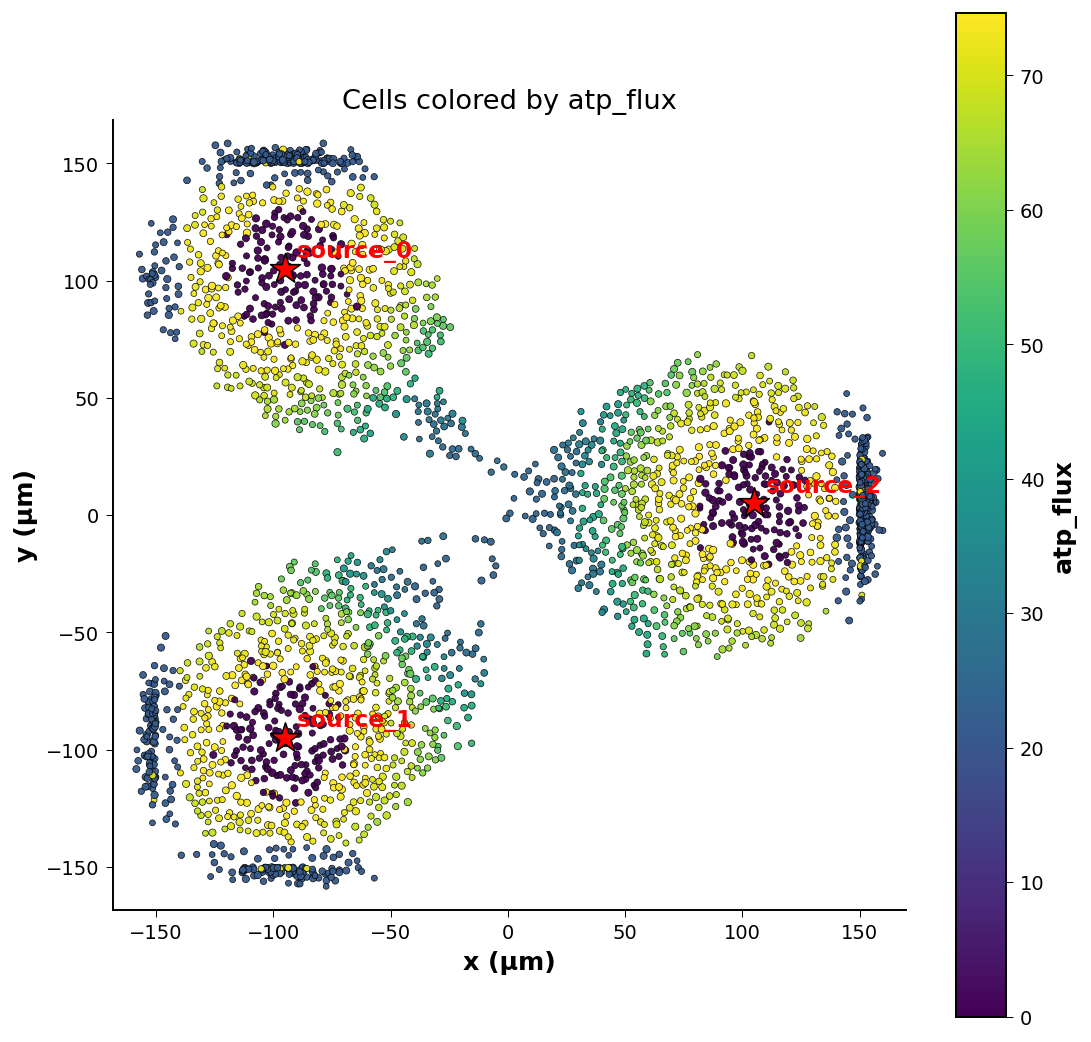

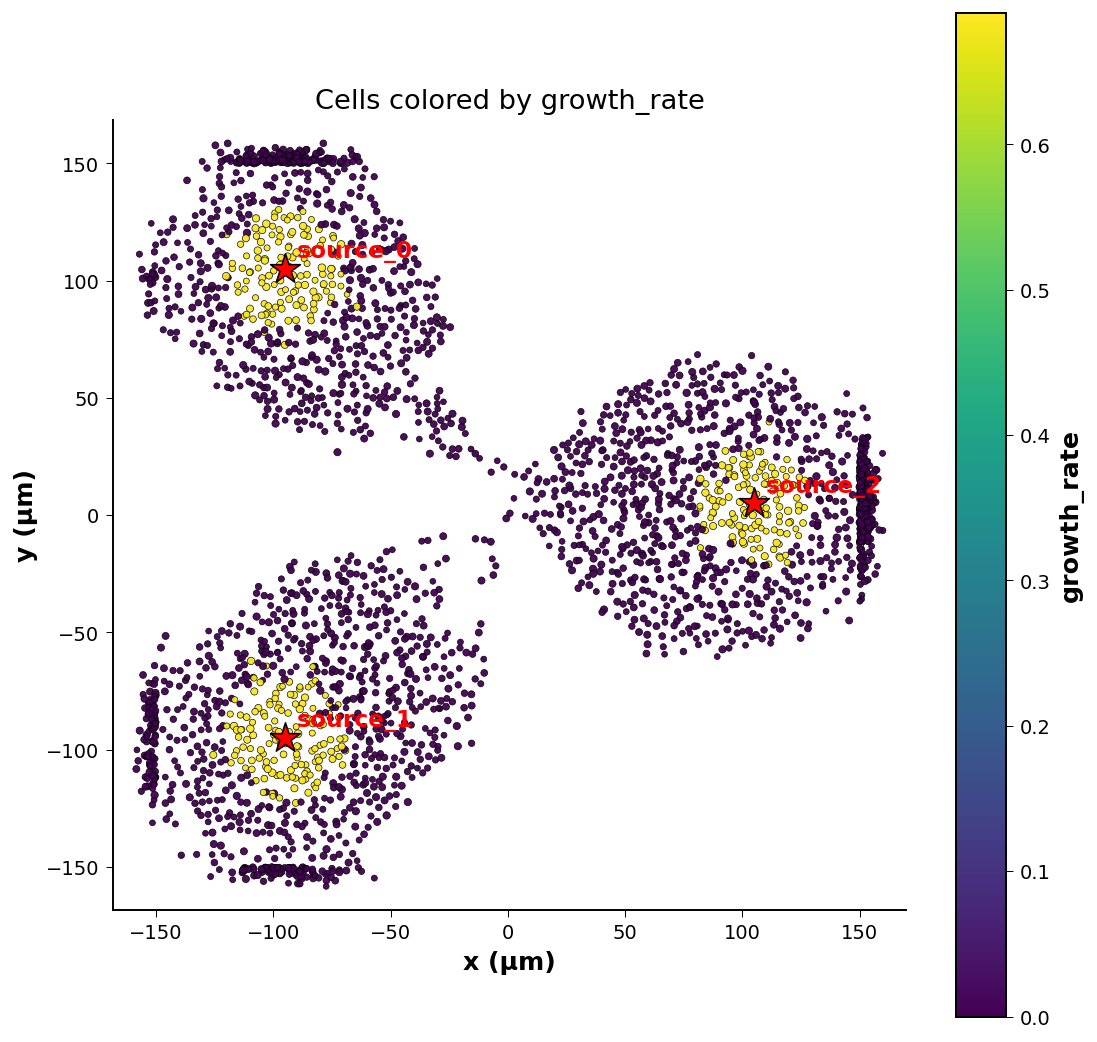

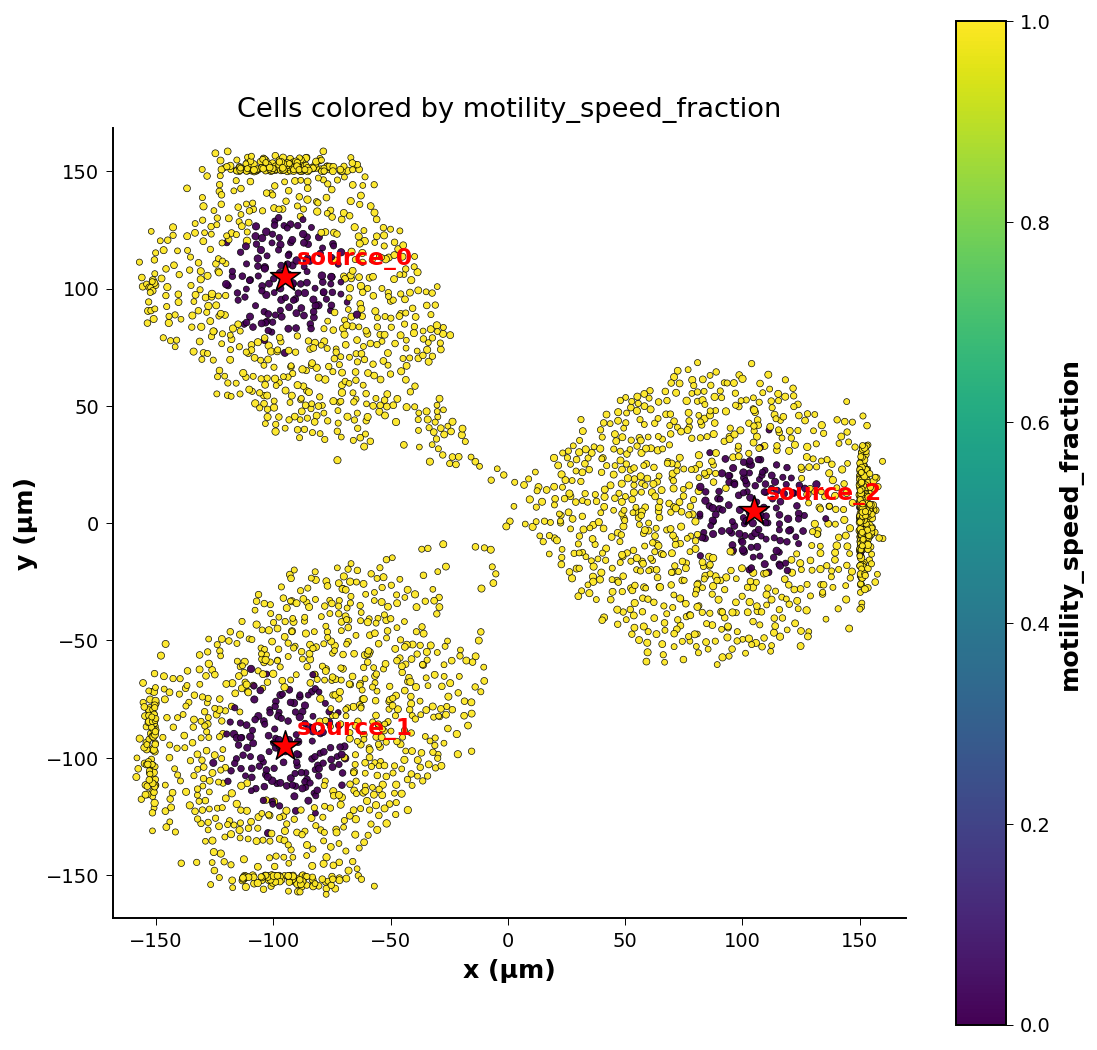

In [36]:
plot_snapshot_as_cells(df_final, color_col="atp_flux")
plot_snapshot_as_cells(df_final, color_col="growth_rate")
plot_snapshot_as_cells(df_final, color_col="motility_speed_fraction")

In [18]:
def radial_profile(df, value_cols, bin_width=10.0, rmax=None):
    out = df.copy()

    if rmax is None:
        rmax = out["distance_to_nearest_source"].max()

    bins = np.arange(0, rmax + bin_width, bin_width)
    out["r_bin"] = pd.cut(out["distance_to_nearest_source"], bins=bins, include_lowest=True)

    grouped = out.groupby("r_bin", observed=False)

    summary = grouped[value_cols].agg(["mean", "std", "count"])

    centers = []
    for interval in summary.index:
        centers.append((interval.left + interval.right) / 2)
    summary["r_center"] = centers

    return summary.reset_index(drop=True)

In [47]:
def plot_radial_profile_two_axes(
    profile,
    atp_col="atp_flux",
    growth_col="growth_rate",
    motility_col="motility_speed_fraction",
    figsize=(9.5, 5.5),
):
    fig, ax1 = plt.subplots(figsize=figsize)

    x = profile["r_center"]

    # explicit colors
    c_atp = "#1f77b4"       # blue
    c_growth = "#d62728"    # red
    c_motility = "#2ca02c"  # green

    # left axis
    l1, = ax1.plot(
        x, profile[(atp_col, "mean")],
        lw=2.8, color=c_atp, label="ATP flux"
    )
    ax1.set_xlabel("Distance to nearest glucose source (µm)", weight="bold")
    ax1.set_ylabel(r"ATP flux (mmol gDW$^{-1}$ h$^{-1}$)", weight="bold")

    # right axis
    ax2 = ax1.twinx()
    l2, = ax2.plot(
        x, profile[(growth_col, "mean")],
        lw=2.6, color=c_growth, label="Growth rate"
    )
    l3, = ax2.plot(
        x, profile[(motility_col, "mean")],
        lw=2.6, color=c_motility, label="Motility speed fraction"
    )
    ax2.set_ylabel("Growth / motility fraction", weight="bold")
    ax2.set_ylim(-0.02, 1.05)

    # cosmetics
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax1.spines["left"].set_color("0.2")
    ax1.spines["bottom"].set_color("0.2")
    ax2.spines["right"].set_color("0.2")

    # legend outside
    lines = [l1, l2, l3]
    labels = [l.get_label() for l in lines]
    ax1.legend(
        lines, labels,
        loc="upper left",
        bbox_to_anchor=(1.05, 1.0),
        frameon=True,
        facecolor="white",
        edgecolor="0.8"
    )

    ax1.set_title("Radial profile")
    plt.tight_layout()
    plt.show()

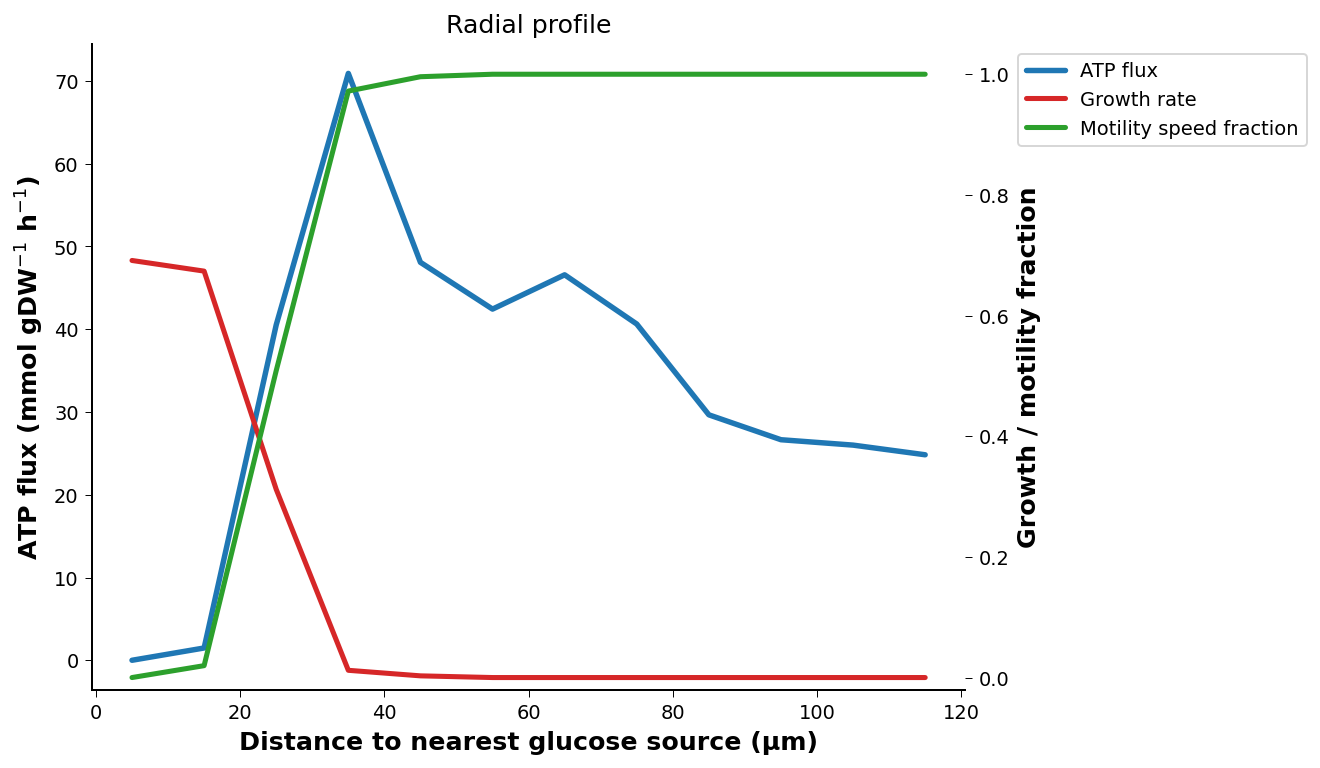

In [48]:
profile = radial_profile(
    df_final,
    value_cols=["atp_flux", "growth_rate", "motility_speed_fraction"],
    bin_width=10.0
)
plot_radial_profile_two_axes(profile)

In [21]:
def colony_counts(df):
    return (
        df.groupby("nearest_source_name", observed=False)
          .size()
          .rename("n_cells")
          .reset_index()
    )

def colony_radius_stats(df):
    return (
        df.groupby("nearest_source_name", observed=False)["distance_to_nearest_source"]
          .agg(
              mean_radius="mean",
              median_radius="median",
              p90_radius=lambda x: np.percentile(x, 90),
              max_radius="max",
              n_cells="count",
          )
          .reset_index()
    )

In [22]:
print(colony_counts(df_final))
print(colony_radius_stats(df_final))

  nearest_source_name  n_cells
0            source_0      835
1            source_1      984
2            source_2     1096
  nearest_source_name  mean_radius  median_radius  p90_radius  max_radius  \
0            source_0    44.888096      46.641579   65.686920  115.808372   
1            source_1    47.863245      50.187760   70.085478  117.487958   
2            source_2    47.697916      47.789263   72.257026  116.012758   

   n_cells  
0      835  
1      984  
2     1096  


In [23]:
def source_means_over_time(df, value_cols):
    return (
        df.groupby(["time", "nearest_source_name"], observed=False)[value_cols]
          .mean()
          .reset_index()
    )

def source_counts_over_time(df):
    return (
        df.groupby(["time", "nearest_source_name"], observed=False)
          .size()
          .rename("n_cells")
          .reset_index()
    )

In [24]:
def plot_source_means_over_time(df_means, value_col, figsize=(8, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    for name, g in df_means.groupby("nearest_source_name", observed=False):
        ax.plot(g["time"], g[value_col], label=name)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(value_col)
    ax.set_title(f"{value_col} over time by source")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_source_counts_over_time(df_counts, figsize=(8, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    for name, g in df_counts.groupby("nearest_source_name", observed=False):
        ax.plot(g["time"], g["n_cells"], label=name)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Number of cells")
    ax.set_title("Cells assigned to each source over time")
    ax.legend()
    plt.tight_layout()
    plt.show()

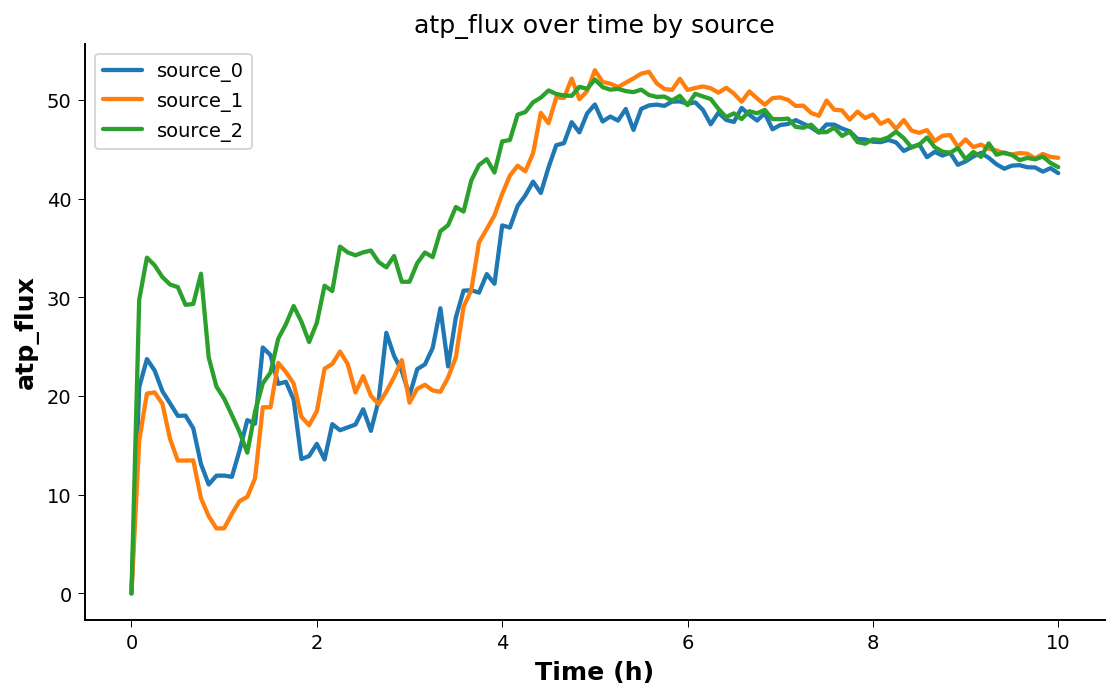

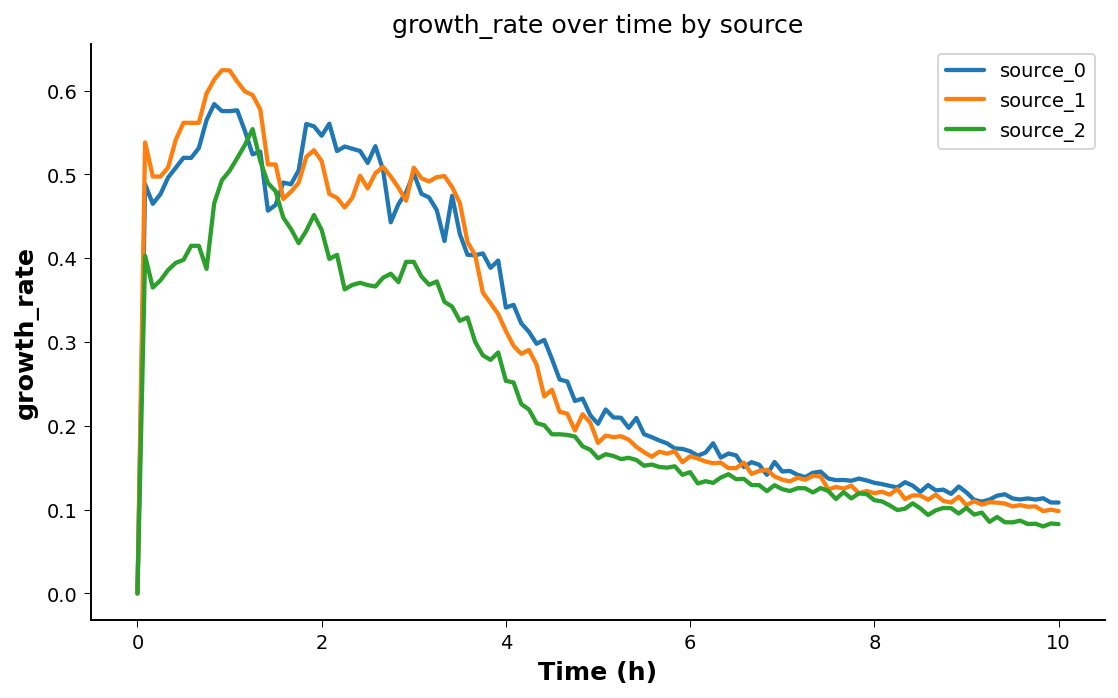

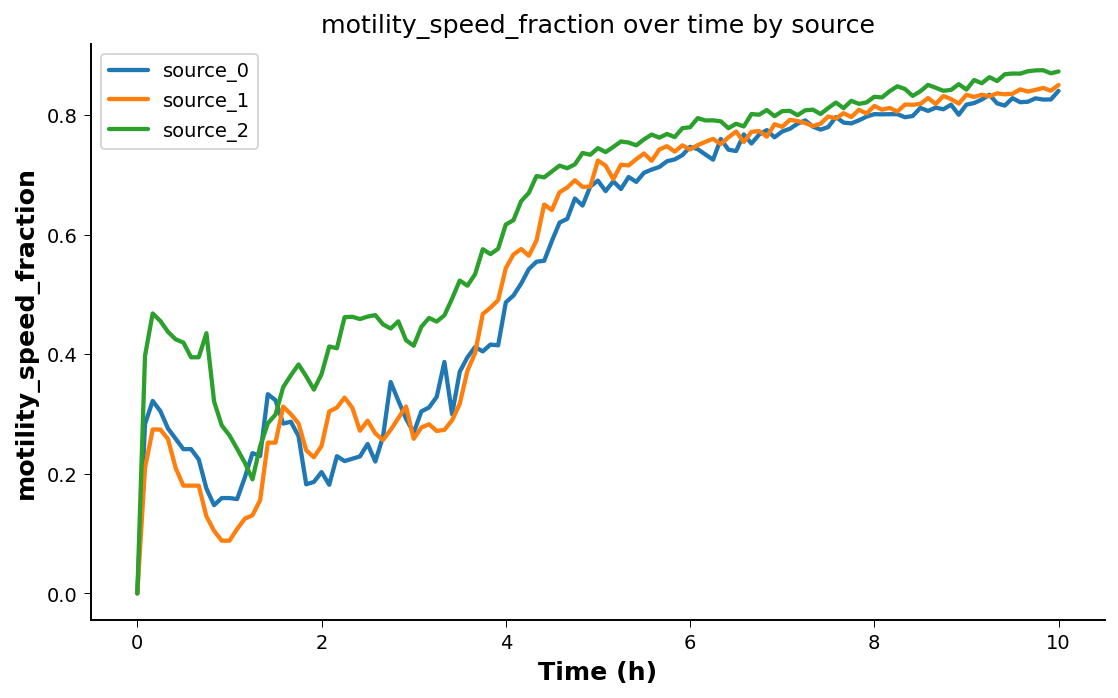

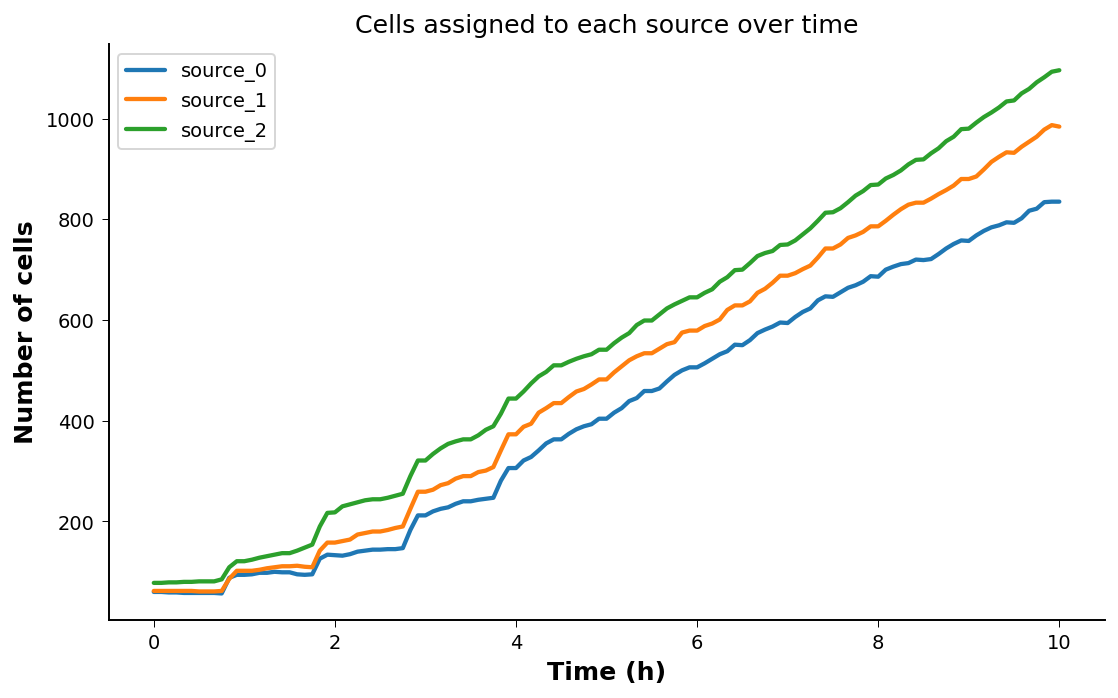

In [25]:
df_means = source_means_over_time(
    df_cells_long,
    ["atp_flux", "growth_rate", "motility_speed_fraction"]
)

df_counts = source_counts_over_time(df_cells_long)

plot_source_means_over_time(df_means, "atp_flux")
plot_source_means_over_time(df_means, "growth_rate")
plot_source_means_over_time(df_means, "motility_speed_fraction")
plot_source_counts_over_time(df_counts)

In [26]:
def classify_core_periphery(df, core_radius=30.0, outer_radius=60.0):
    out = df.copy()
    r = out["distance_to_nearest_source"]

    out["region"] = "mid"
    out.loc[r <= core_radius, "region"] = "core"
    out.loc[r >= outer_radius, "region"] = "periphery"
    return out

def summarize_by_region(df, value_cols):
    return (
        df.groupby("region", observed=False)[value_cols]
          .agg(["mean", "std", "count"])
    )

In [27]:
df_regions = classify_core_periphery(df_final, core_radius=30, outer_radius=60)
summary_regions = summarize_by_region(
    df_regions,
    ["atp_flux", "growth_rate", "motility_speed_fraction"]
)
print(summary_regions)

            atp_flux                  growth_rate                  \
                mean        std count        mean       std count   
region                                                              
core       21.497534  33.808504   555    0.488683  0.311315   555   
mid        51.102381  24.387044  1768    0.003830  0.050798  1768   
periphery  40.700201  14.360621   592    0.000000  0.000000   592   

          motility_speed_fraction                  
                             mean       std count  
region                                             
core                     0.270270  0.444500   555  
mid                      0.992081  0.088658  1768  
periphery                1.000000  0.000000   592  


In [28]:
df_global_check = (
    df_cells_long.groupby("time", observed=False)[
        ["growth_rate", "atp_flux", "motility_atp_flux", "motility_speed_fraction"]
    ]
    .mean()
    .reset_index()
    .set_index("time")
)

print(df_global_check)

           growth_rate   atp_flux  motility_atp_flux  motility_speed_fraction
time                                                                         
0.000000      0.000000   0.000000           0.000000                 0.000000
0.083333      0.470426  22.683167          22.528167                 0.305000
0.166667      0.435575  26.732277          26.549777                 0.365000
0.250000      0.442360  26.122146          25.944646                 0.355000
0.333333      0.455980  24.733619          24.566119                 0.335000
...                ...        ...                ...                      ...
9.666667      0.098650  44.016202          43.588110                 0.847350
9.750000      0.098459  43.797416          43.369169                 0.850543
9.833333      0.095806  43.930819          43.500619                 0.851071
9.916667      0.096271  43.689108          43.259263                 0.847684
10.000000     0.095366  43.353228          42.922696            

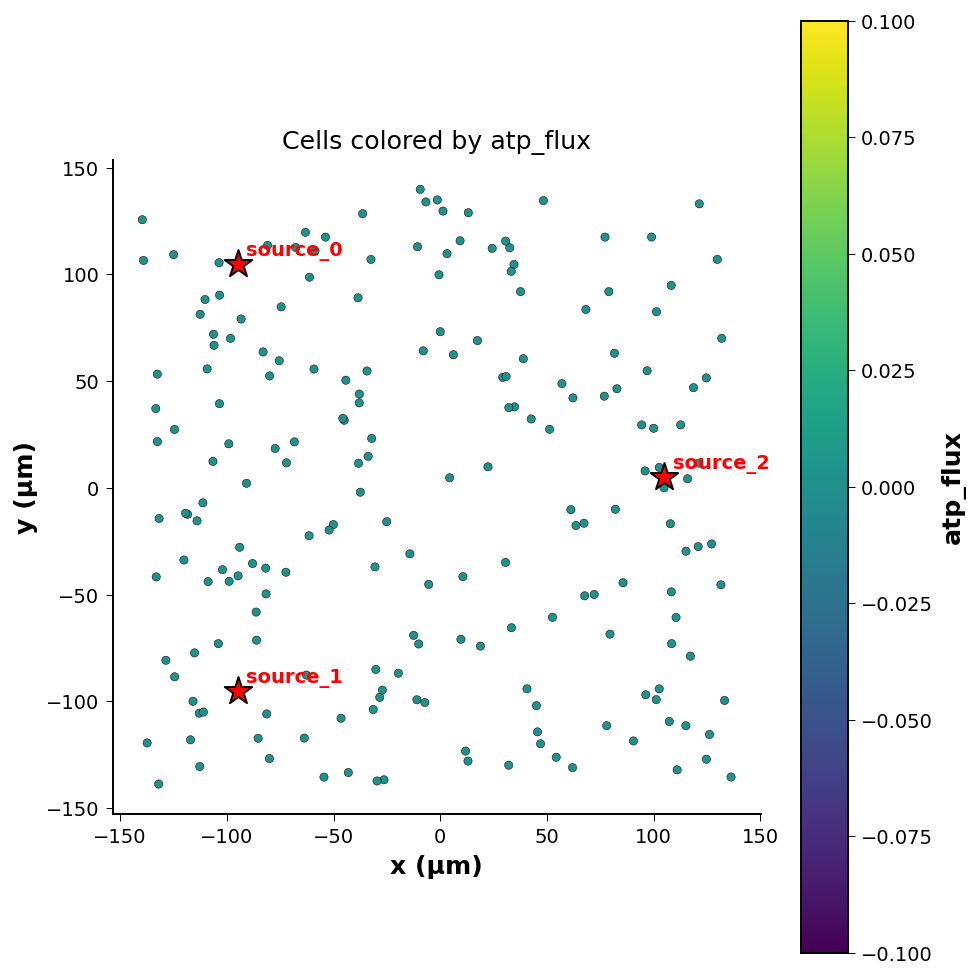

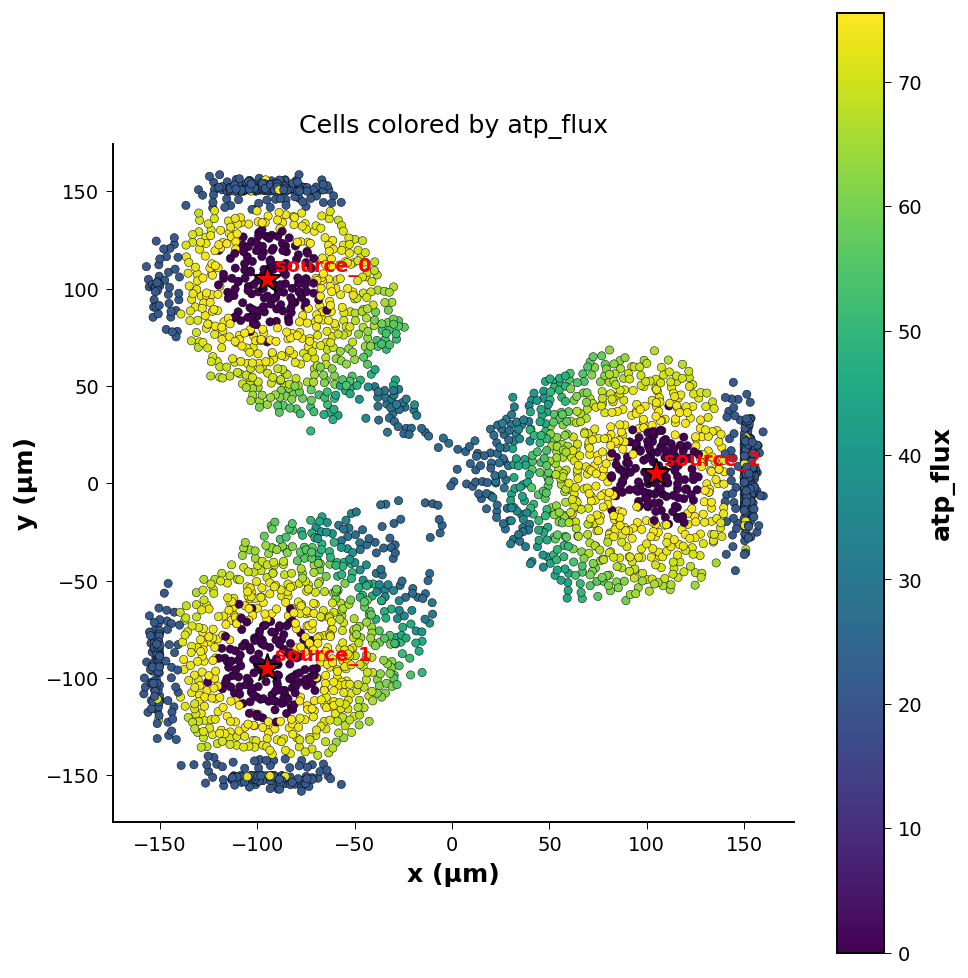

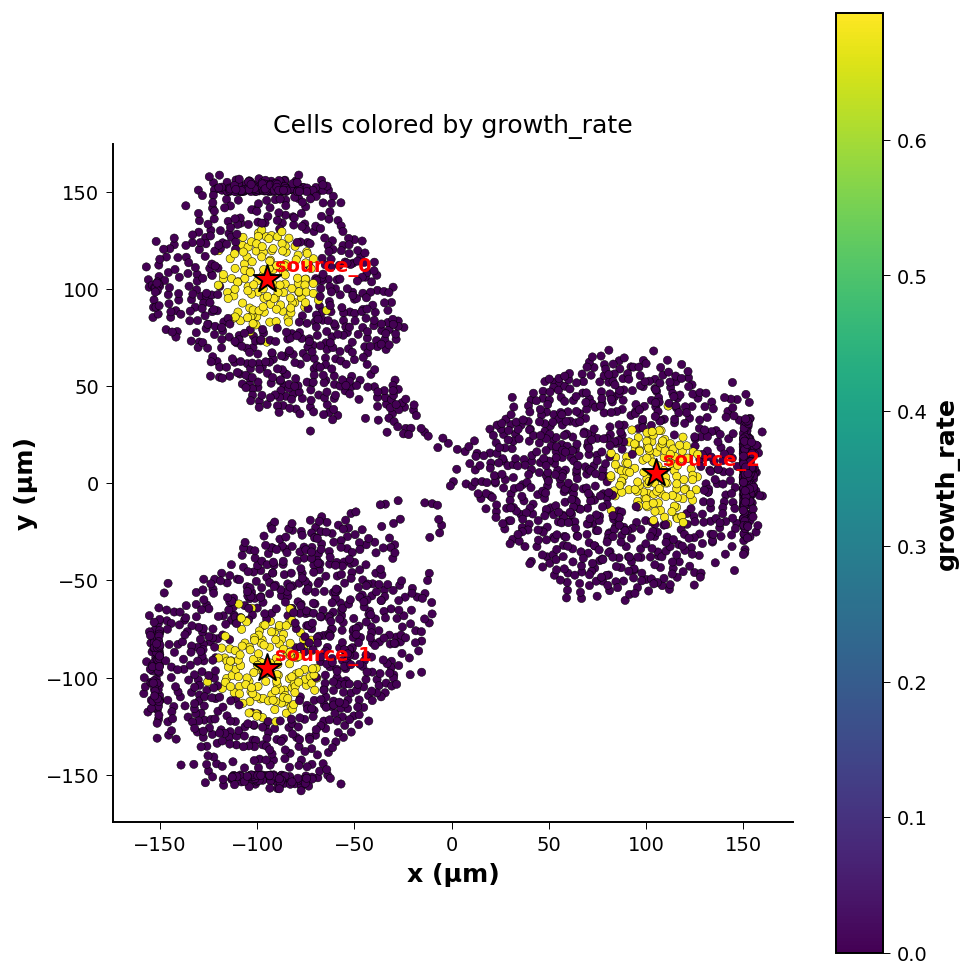

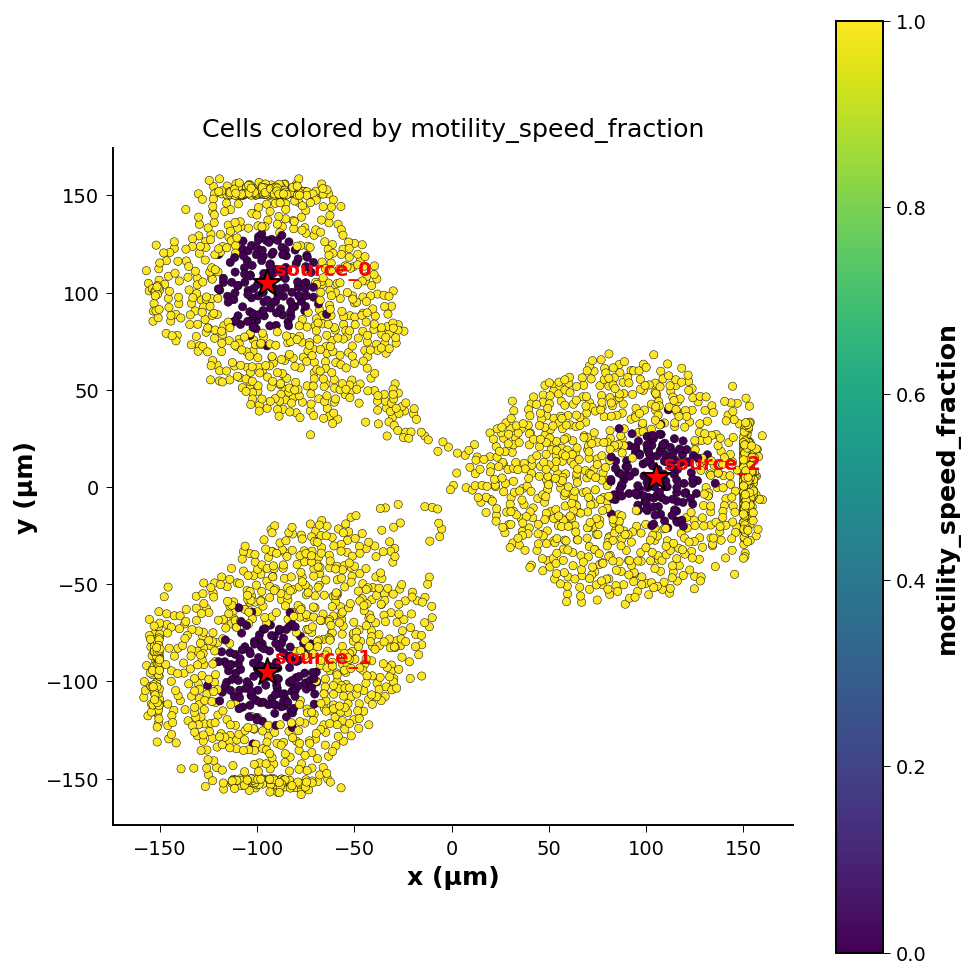

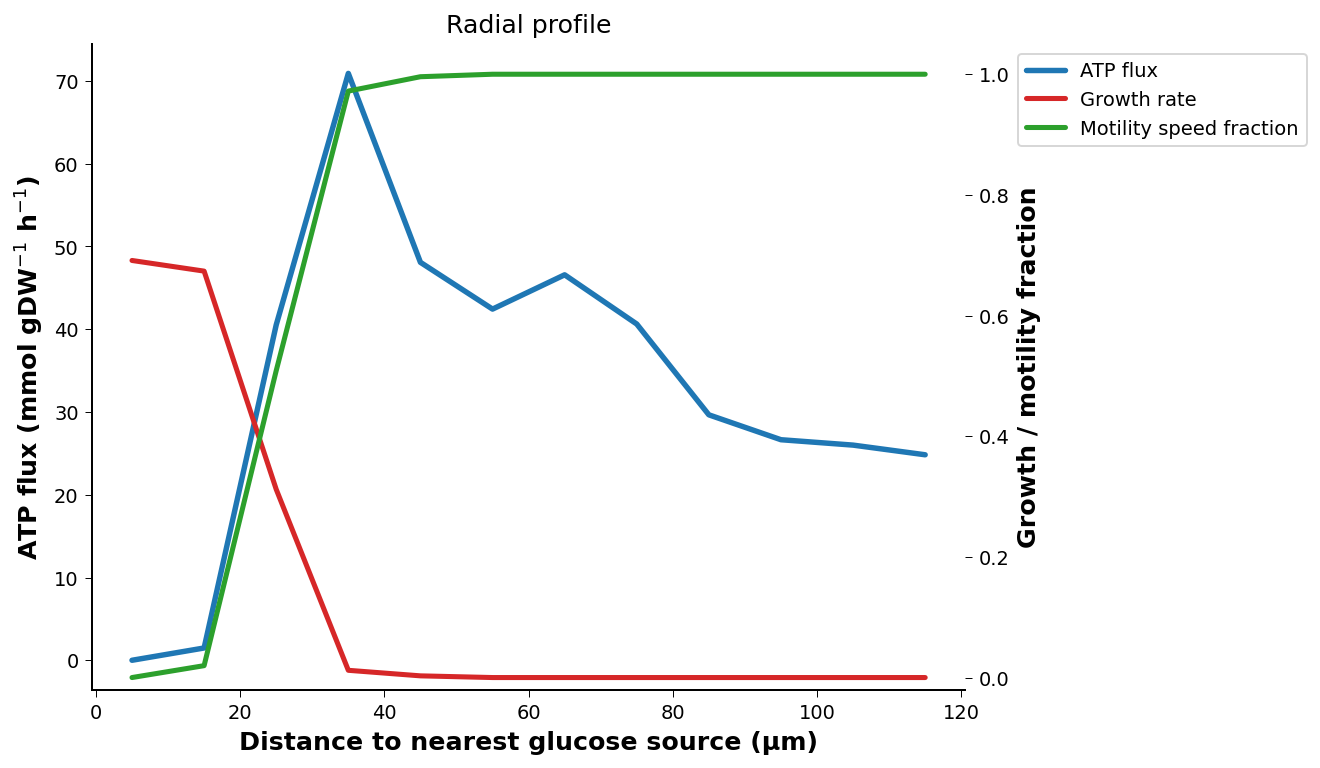

  nearest_source_name  n_cells
0            source_0      835
1            source_1      984
2            source_2     1096
  nearest_source_name  mean_radius  median_radius  p90_radius  max_radius  \
0            source_0    44.888096      46.641579   65.686920  115.808372   
1            source_1    47.863245      50.187760   70.085478  117.487958   
2            source_2    47.697916      47.789263   72.257026  116.012758   

   n_cells  
0      835  
1      984  
2     1096  


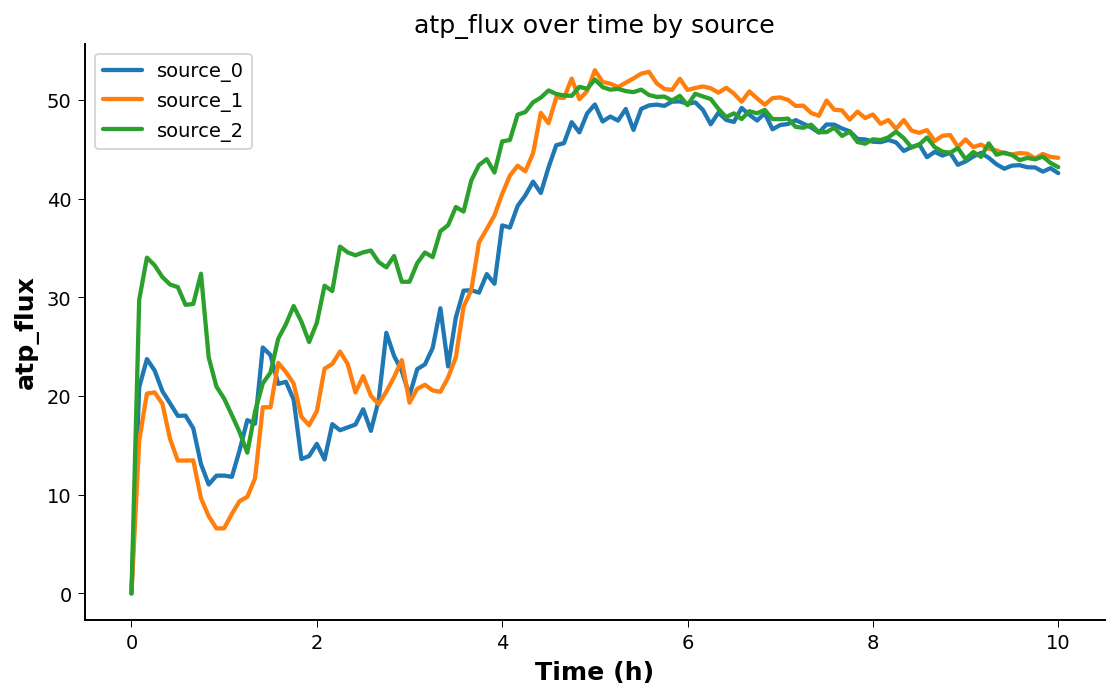

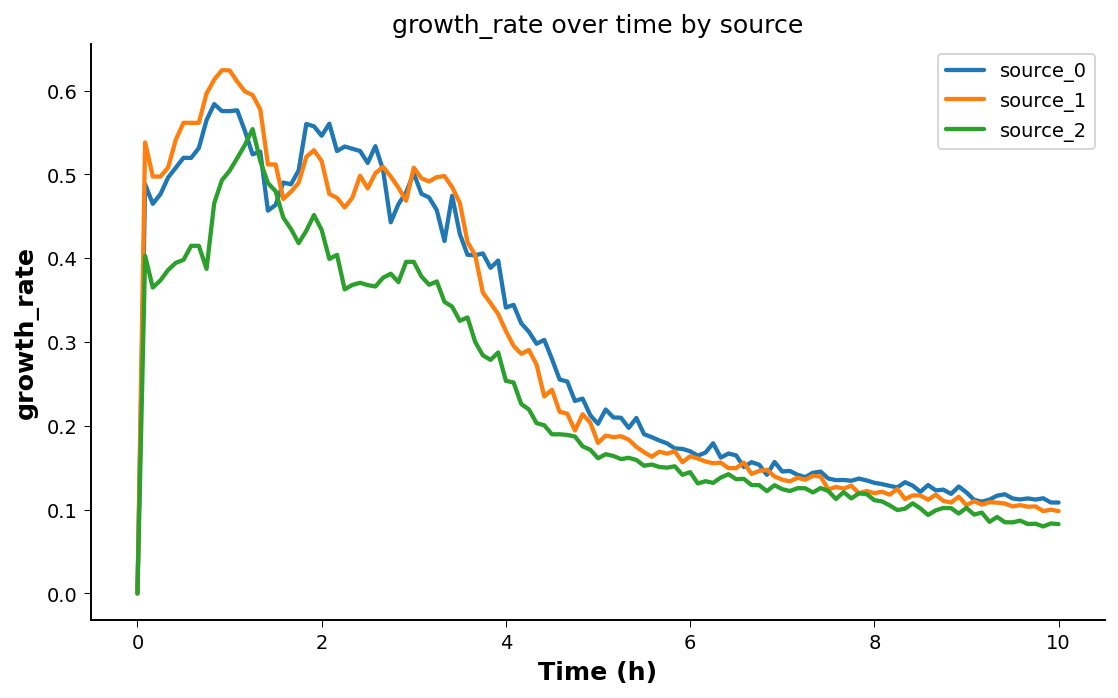

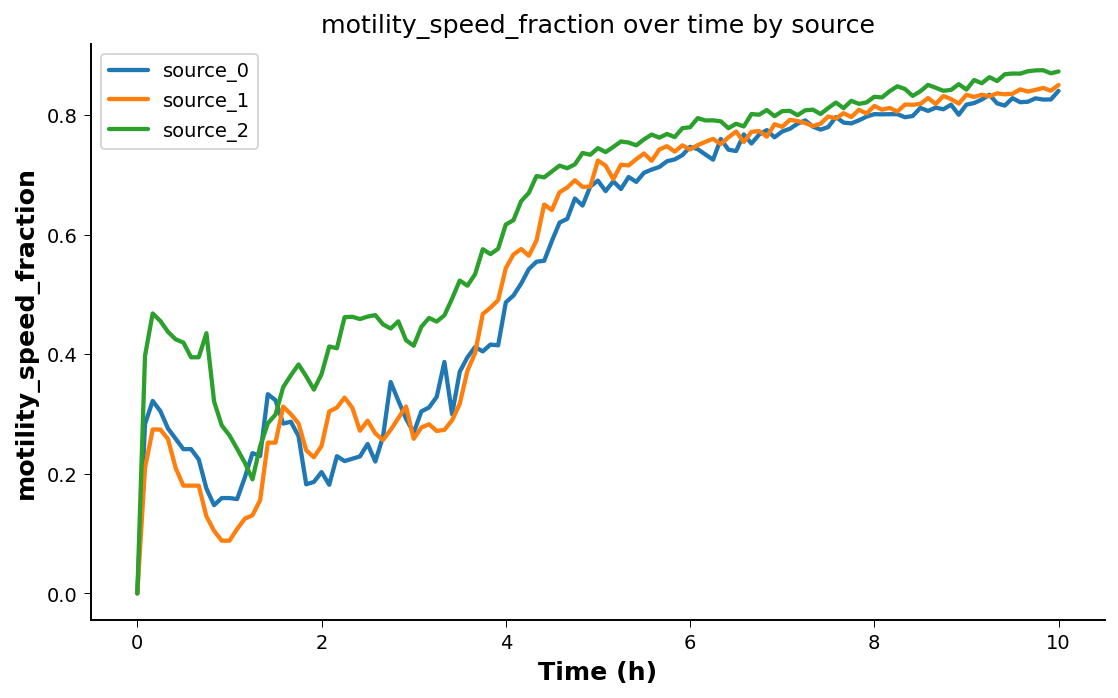

In [50]:
t0, df0 = get_snapshot(df_cells_long, 0.0)
tf, dff = get_snapshot(df_cells_long, df_cells_long["time"].max())

plot_snapshot(df0, color_col="atp_flux")
plot_snapshot(dff, color_col="atp_flux")
plot_snapshot(dff, color_col="growth_rate")
plot_snapshot(dff, color_col="motility_speed_fraction")

profile_final = radial_profile(
    dff,
    value_cols=["atp_flux", "growth_rate", "motility_speed_fraction"],
    bin_width=10.0
)
plot_radial_profile_two_axes(profile_final)

print(colony_counts(dff))
print(colony_radius_stats(dff))

df_means = source_means_over_time(
    df_cells_long,
    ["atp_flux", "growth_rate", "motility_speed_fraction"]
)
plot_source_means_over_time(df_means, "atp_flux")
plot_source_means_over_time(df_means, "growth_rate")
plot_source_means_over_time(df_means, "motility_speed_fraction")